In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import joblib


df = pd.read_csv("DelayedFlights.csv")

In [2]:
#df.head(100)
#df.info()
#df.describe()
#len(df)
df.isnull().sum()



Unnamed: 0                0
Year                      0
Month                     0
DayofMonth                0
DayOfWeek                 0
DepTime                   0
CRSDepTime                0
ArrTime                7110
CRSArrTime                0
UniqueCarrier             0
FlightNum                 0
TailNum                   5
ActualElapsedTime      8387
CRSElapsedTime          198
AirTime                8387
ArrDelay               8387
DepDelay                  0
Origin                    0
Dest                      0
Distance                  0
TaxiIn                 7110
TaxiOut                 455
Cancelled                 0
CancellationCode          0
Diverted                  0
CarrierDelay         689270
WeatherDelay         689270
NASDelay             689270
SecurityDelay        689270
LateAircraftDelay    689270
dtype: int64

In [3]:
# عدد القيم المفقودة في كل عمود منهم
#ArrTime                7110وقت وصول الرحلة.
#TailNum                   5رقم ذيل الطائرة.
# ActualElapsedTime      8387الوقت الفعلي المستغرق في الرحلة
#CRSElapsedTime          198الوقت المجدول المستغرق.
#AirTime                8387الوقت الذي كانت فيه الطائرة في الهواء.
#ArrDelay               8387تأخير الوصول.
#TaxiIn                 7110الوقت المستغرق في التاكسي عند الوصول
#TaxiOut                 455الوقت المستغرق في التاكسي قبل المغادرة.
#CarrierDelay         689270تأخير بسبب الناقل الجوي.
#WeatherDelay         689270
#NASDelay             689270تأخير بسبب نظام إدارة الملاحة الجوية
#SecurityDelay        689270تأخير بسبب إجراءات الأمان.
#LateAircraftDelay    689270 أخير بسبب طائرة سابقة

2
Original shape: (1928371, 28)
After clipping shape: (1928371, 28)
After deleting outliers shape: (1664407, 28)
Deleted rows: 263964


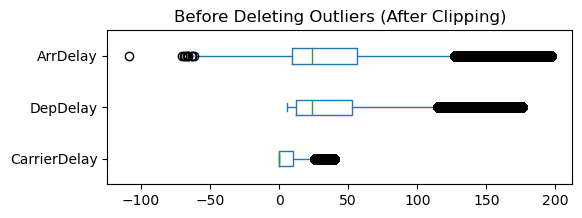

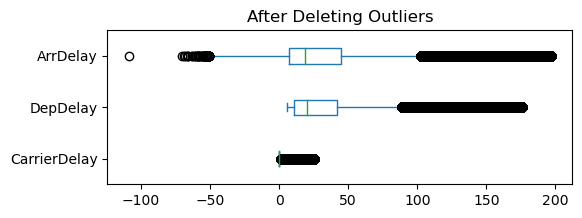

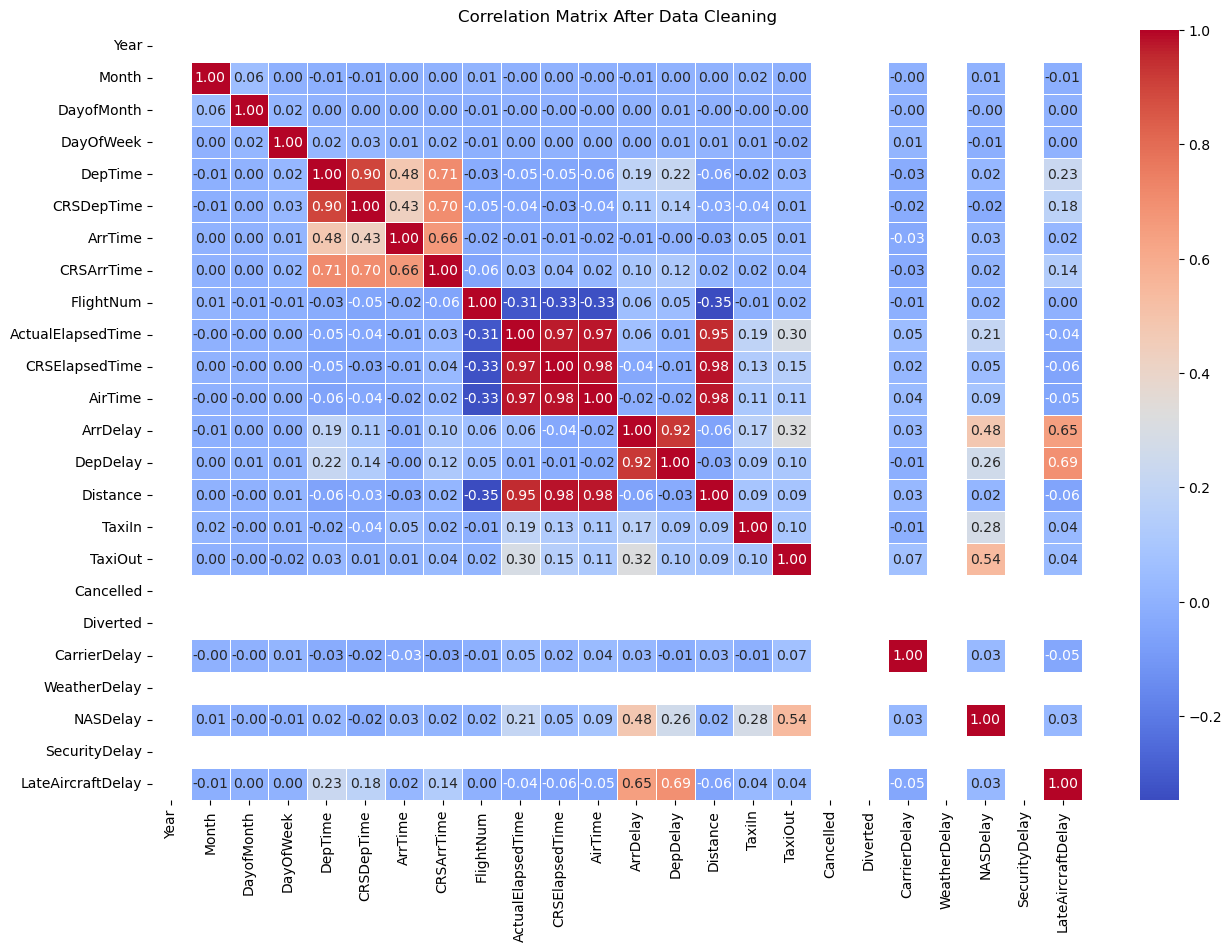

In [4]:

# ____data cleansing__

df = df[df['CRSElapsedTime'].notna()]  # مسحت الصفوف اللي فيها قيم ناقصة
df.drop('TailNum', axis=1, inplace=True) # مسحت العمود
df = df[df['TaxiOut'].notna()]
df['TaxiIn'].fillna(df['TaxiIn'].median(), inplace=True)
df.dropna(subset=['ArrTime', 'ActualElapsedTime', 'AirTime', 'ArrDelay'], inplace=True)

delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
df[delay_cols] = df[delay_cols].fillna(0)

df = df.drop(columns=['Unnamed: 0'])

df_clean = df.copy()
print(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()

# converting some data types
categorical_cols = ['UniqueCarrier', 'Origin', 'Dest', 'CancellationCode']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# outliers handling
columns_to_clip = ['ArrDelay', 'DepDelay', 'AirTime', 'TaxiIn', 'TaxiOut', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

def clip_outliers(df, columns):
    df_clipped = df.copy()
    for col in columns:
        Q1 = df_clipped[col].quantile(0.25)
        Q3 = df_clipped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        df_clipped[col] = df_clipped[col].clip(lower=lower_bound, upper=upper_bound)
    return df_clipped

df_clipped = clip_outliers(df, columns_to_clip)

columns_to_delete = ['CarrierDelay', 'DepDelay', 'ArrDelay']

def delete_outliers(df, columns):
    df_deleted = df.copy()
    for col in columns:
        Q1 = df_deleted[col].quantile(0.25)
        Q3 = df_deleted[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_deleted = df_deleted[(df_deleted[col] >= lower_bound) & (df_deleted[col] <= upper_bound)]
        return df_deleted

df_final = delete_outliers(df_clipped, columns_to_delete)

print("Original shape:", df.shape)
print("After clipping shape:", df_clipped.shape)
print("After deleting outliers shape:", df_final.shape)
print("Deleted rows:", df_clipped.shape[0] - df_final.shape[0])

df_clipped[columns_to_delete].plot(kind='box', vert=False, figsize=(6, 2))
plt.title("Before Deleting Outliers (After Clipping)")
plt.show()

df_final[columns_to_delete].plot(kind='box', vert=False, figsize=(6, 2))
plt.title("After Deleting Outliers")
plt.show()

corr_after = df_final.corr(numeric_only=True)

plt.figure(figsize=(15, 10))
sns.heatmap(corr_after, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix After Data Cleaning")
plt.show()



In [5]:
# ------------------- Model -------------------

columns_to_drop = ['ArrDelay', 'DepDelay', 'Cancelled', 'ActualElapsedTime']
X = df_clean.drop(columns=columns_to_drop, errors='ignore')
y = df_clean['ArrDelay']

# encoding categorical columns
X = pd.get_dummies(X, columns=['UniqueCarrier', 'Origin', 'Dest', 'CancellationCode'], drop_first=True)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# normalization
means = X_train.mean()
stds = X_train.std()

valid_column = stds[stds != 0].index
X_train = X_train[valid_column]
X_test = X_test[valid_column]
means = means[valid_column]
stds = stds[valid_column]

X_train_scaled = (X_train - means) / stds
X_test_scaled = (X_test - means) / stds

# Feature Selection
selector = SelectKBest(score_func=f_regression, k=5)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)



In [ ]:
# ----------------- Manual Linear Regression -----------------

# Add bias (column of ones)
X_train_bias = np.c_[np.ones((X_train_selected.shape[0], 1)), X_train_selected]
X_test_bias = np.c_[np.ones((X_test_selected.shape[0], 1)), X_test_selected]



# Compute weights: w = (X^T X)^(-1) X^T y
XTX = X_train_bias.T.dot(X_train_bias)
XTy = X_train_bias.T.dot(y_train)
weights = np.linalg.inv(XTX).dot(XTy)

# separate bias and coefficients
bias = weights[0]
coefficients = weights[1:]

# predictions
y_pred = X_test_bias.dot(weights)

# evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

# ----------------- Feature Importance -----------------

features = X_train.columns[selector.get_support()]
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
})

feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("Reasons for flight delays:")
print(feature_importance[['Feature', 'Coefficient']])

Mean Squared Error: 26.16757541907347
R² Score: 0.9919083553706949
Reasons for flight delays:
             Feature  Coefficient
1       CarrierDelay    35.626429
4  LateAircraftDelay    35.280519
3           NASDelay    27.641867
2       WeatherDelay    17.216273
0            TaxiOut     0.003032


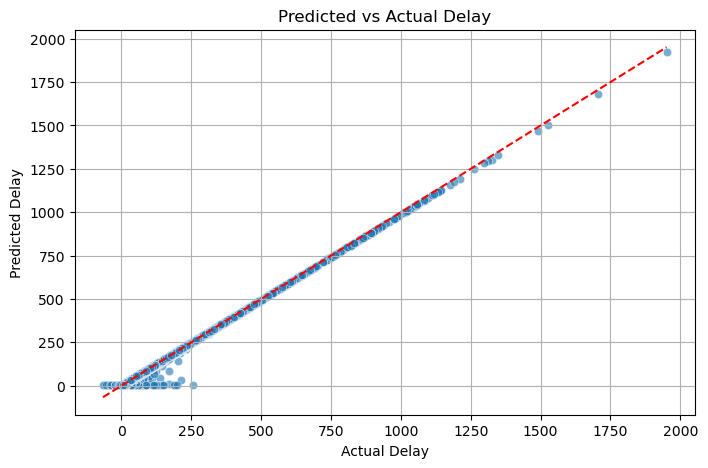

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Predicted vs Actual Delay")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # خط المثالية
plt.grid(True)
plt.show()

In [9]:
## testing 

# حفظ الـ weights الناتجة عن الـ Manual Linear Regression
joblib.dump(weights, 'manual_linear_weights.pkl')

# حفظ الـ selector اللي بيختار أهم 5 features
joblib.dump(selector, 'feature_selector.pkl')

# حفظ المتوسط والانحراف المعياري للـ features المستخدمة في التطبيع
joblib.dump(means, 'feature_means.pkl')
joblib.dump(stds, 'feature_stds.pkl')

print("Model and preprocessing objects saved successfully.")


Model and preprocessing objects saved successfully.


In [10]:
# تحميل الـ weights اللي حسبتيها يدوياً
weights = joblib.load('manual_linear_weights.pkl')

# تحميل بقية objects الخاصة بالـ preprocessing
selector = joblib.load('feature_selector.pkl')
means = joblib.load('feature_means.pkl')
stds = joblib.load('feature_stds.pkl')

# تحميل البيانات الجديدة
new_data = pd.read_csv(r"C:\Users\lenovo\Desktop\datascience\new_data.csv")

# One-Hot Encoding لنفس الأعمدة
new_data = pd.get_dummies(new_data, columns=['UniqueCarrier', 'Origin', 'Dest', 'CancellationCode'], drop_first=True)

# إضافة الأعمدة الناقصة = 0 عشان تتوافق مع اللي اتدرّب عليه
missing_cols = list(set(means.index) - set(new_data.columns))
missing_df = pd.DataFrame(0, index=new_data.index, columns=missing_cols)
new_data = pd.concat([new_data, missing_df], axis=1)

# ترتيب الأعمدة بنفس ترتيب means اللي اتحفظ
new_data = new_data[means.index]

# التطبيع (Scaling)
new_scaled = (new_data - means) / stds

# اختيار أهم 5 features بنفس selector
new_selected = selector.transform(new_scaled)

# إضافة Bias column (ones) زي ما عملتي في التدريب
X_bias = np.c_[np.ones((new_selected.shape[0], 1)), new_selected]

# التنبؤ اليدوي:  y = X . weights
predictions = X_bias.dot(weights)

# طباعة النتائج
for i, pred in enumerate(predictions):
    print(f"Prediction {i+1}: {pred}")

# حفظ النتائج داخل الملف
output = new_data.copy()
output['Predicted_ArrDelay'] = predictions

Prediction 1: 31.46787035483499
Prediction 2: 11.805109090363299
